# Mitigating the Hivemind: A Ladder of Interventions

In [ ]:
!pip install -q transformers peft accelerate bitsandbytes sentence-transformers scipy matplotlib pandas seaborn

import numpy as np
import torch
import json, re, os, random, time
from typing import List, Dict, Tuple, Set, Optional
from dataclasses import dataclass, field
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,
    LogitsProcessor, LogitsProcessorList
)
from peft import PeftModel
from sentence_transformers import SentenceTransformer

print('Imports OK | CUDA:', torch.cuda.is_available())

Imports OK | CUDA: True


In [ ]:
@dataclass
class Config:
    base_model_id: str = 'mistralai/Mistral-7B-Instruct-v0.2'
    embed_model_id: str = 'sentence-transformers/all-MiniLM-L6-v2'

    adapters: Dict[str, str] = field(default_factory=lambda: {
        'africa':       'bunsenfeng/mistral-africa_culture',
        'asia':         'bunsenfeng/mistral-asia_culture',
        'europe':       'bunsenfeng/mistral-europe_culture',
        'northamerica': 'bunsenfeng/mistral-northamerica_culture',
        'southamerica': 'bunsenfeng/mistral-southamerica_culture',
    })

    prompts: List[str] = field(default_factory=lambda: [
        'What does home mean to you?',
        'How should we treat strangers?',
        'What is the purpose of suffering?',
        'What makes a good leader?',
        'Describe what justice looks like.',
        'What is the most important thing in life?',
        'How should society handle disagreement?',
        'What does it mean to be brave?',
        'What role should elders play in society?',
        'How do you know when something is true?',
        'What obligations do we owe to future generations?',
        'Is it better to be honest or kind?',
        'What does forgiveness require?',
        'How should wealth be shared?',
        'What makes a life meaningful?',
    ])

    K: int = 30
    M_multiplier: float = 2.0
    max_new_tokens: int = 200
    temperature: float = 0.9
    top_p: float = 0.92
    seed: int = 42

    repulsion_ngram_sizes: List[int] = field(default_factory=lambda: [2, 3, 4])
    repulsion_penalty: float = 5.0

    dpp_quality_weight: float = 0.5

    output_dir: str = './hivemind_ladder_results'

    batch_size: int = 16

    @property
    def M(self): return int(self.K * self.M_multiplier)


cfg = Config()
os.makedirs(cfg.output_dir, exist_ok=True)
np.random.seed(cfg.seed); torch.manual_seed(cfg.seed); random.seed(cfg.seed)
ADAPTER_NAMES = list(cfg.adapters.keys())

print(f'Config OK | K={cfg.K} | batch_size={cfg.batch_size}')
print(f'7 conditions × {len(cfg.prompts)} prompts × {cfg.K} = {7*len(cfg.prompts)*cfg.K} total generations (+ overgen for DPP)')


Config OK | K=30 | batch_size=16
7 conditions × 15 prompts × 30 = 3150 total generations (+ overgen for DPP)


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(cfg.base_model_id, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = 'left'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
)
base_model = AutoModelForCausalLM.from_pretrained(
    cfg.base_model_id, quantization_config=bnb_config,
    device_map={'': 0}, low_cpu_mem_usage=True,
)

first = ADAPTER_NAMES[0]
model = PeftModel.from_pretrained(
    base_model, cfg.adapters[first],
    adapter_name=first, is_trainable=False
)
for name in ADAPTER_NAMES[1:]:
    model.load_adapter(cfg.adapters[name], adapter_name=name, is_trainable=False)
model.eval()

embed_model = SentenceTransformer(cfg.embed_model_id)
print(f'Loaded | VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB')

config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded | VRAM: 4.3 GB


In [ ]:
def format_prompt(content: str) -> str:
    return tokenizer.apply_chat_template(
        [{'role': 'user', 'content': content}],
        tokenize=False, add_generation_prompt=True
    )


class CrossResponseRepulsionProcessor(LogitsProcessor):
    def __init__(self, ngram_sizes, penalty, prompt_lengths):
        self.ngram_sizes = ngram_sizes
        self.penalty = penalty
        self.prompt_lengths = prompt_lengths if isinstance(prompt_lengths, list) else [prompt_lengths]
        self.memories = [{n: set() for n in ngram_sizes} for _ in self.prompt_lengths]

    def add_response(self, idx, token_ids):
        for n in self.ngram_sizes:
            for i in range(len(token_ids) - n + 1):
                self.memories[idx][n].add(tuple(token_ids[i:i+n]))

    def __call__(self, input_ids, scores):
        batch_size = input_ids.shape[0]
        for b in range(batch_size):
            mem = self.memories[b] if b < len(self.memories) else self.memories[0]
            if not any(mem[n] for n in self.ngram_sizes):
                continue
            pl = self.prompt_lengths[b] if b < len(self.prompt_lengths) else self.prompt_lengths[0]
            generated = input_ids[b][pl:].tolist()
            for n in self.ngram_sizes:
                if len(generated) < n - 1:
                    continue
                context = tuple(generated[-(n-1):])
                for ngram in mem[n]:
                    if ngram[:-1] == context and ngram[-1] < scores.shape[-1]:
                        scores[b, ngram[-1]] -= self.penalty
        return scores


@torch.inference_mode()
def generate(prompt_text, max_new_tokens=None, temperature=None,
             repulsion=None):
    max_new_tokens = max_new_tokens or cfg.max_new_tokens
    temperature = temperature or cfg.temperature
    inputs = tokenizer(
        prompt_text, return_tensors='pt',
        truncation=True, max_length=1024, add_special_tokens=False
    ).to(model.device)
    prompt_len = inputs['input_ids'].shape[1]

    if repulsion:
        repulsion.prompt_lengths = [prompt_len]

    outputs = model.generate(
        **inputs, max_new_tokens=max_new_tokens,
        temperature=temperature, top_p=cfg.top_p,
        do_sample=True, repetition_penalty=1.1,
        pad_token_id=tokenizer.pad_token_id,
        logits_processor=LogitsProcessorList([repulsion] if repulsion else []),
    )
    new_ids = outputs[0][prompt_len:].tolist()
    text = tokenizer.decode(new_ids, skip_special_tokens=True).strip()
    return text, new_ids


@torch.inference_mode()
def generate_batch(prompt_texts, max_new_tokens=None, temperature=None,
                   repulsion=None, batch_size=None):
    max_new_tokens = max_new_tokens or cfg.max_new_tokens
    temperature = temperature or cfg.temperature
    bs = batch_size or cfg.batch_size
    results = [None] * len(prompt_texts)

    for start in range(0, len(prompt_texts), bs):
        chunk = prompt_texts[start : start + bs]
        inputs = tokenizer(
            chunk, return_tensors='pt', padding=True,
            truncation=True, max_length=1024, add_special_tokens=False
        ).to(model.device)

        prompt_lengths = (inputs['attention_mask'].sum(dim=1)).tolist()

        if repulsion:
            repulsion.prompt_lengths = prompt_lengths

        outputs = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            temperature=temperature, top_p=cfg.top_p,
            do_sample=True, repetition_penalty=1.1,
            pad_token_id=tokenizer.pad_token_id,
            logits_processor=LogitsProcessorList([repulsion] if repulsion else []),
        )

        for i, (out, pl) in enumerate(zip(outputs, prompt_lengths)):
            new_ids = out[pl:].tolist()
            new_ids = [t for t in new_ids if t != tokenizer.pad_token_id]
            text = tokenizer.decode(new_ids, skip_special_tokens=True).strip()
            results[start + i] = (text, new_ids)

    return results


def embed_texts(texts):
    return embed_model.encode(texts, batch_size=64,
                              show_progress_bar=False, normalize_embeddings=True)

with model.disable_adapter():
    t, _ = generate(format_prompt('Say one word.'), max_new_tokens=10)
    print('Smoke:', t)
    pair = generate_batch([format_prompt('Say hello.'), format_prompt('Say bye.')],
                          max_new_tokens=10)
    print('Batch smoke:', [r[0] for r in pair])


Smoke: Challenge. (I couldn't resist adding a
Batch smoke: ["Hello! It's nice to meet you.", 'Goodbye! It was nice interacting with you']


In [ ]:
CULTURAL_EXEMPLARS = {
    'What does home mean to you?': [
        ('West African', 'Home is the compound where my extended family lives together across generations. It is the land where my ancestors are buried and where their spirits guide us. Home is not a building — it is the people who share your blood and your stories.'),
        ('Japanese', 'Home is the place of harmony and order. It is where one fulfills duties to family, where shoes are removed at the entrance as a sign of respect for the shared space. Home carries the weight of generations of obligation and care.'),
        ('Brazilian', 'Home is wherever the family gathers — it could be a grandmother\'s kitchen during Sunday lunch, or a crowded apartment full of cousins laughing. Home is warmth, noise, music, and the feeling that you never have to explain yourself.'),
        ('Scandinavian', 'Home is a refuge of privacy and simplicity. It is hygge — a candle burning, a book, silence. Home means independence and self-sufficiency. Everyone has their own space and respects each other\'s boundaries.'),
        ('Indian', 'Home is the joint family under one roof. It is the tulsi plant in the courtyard, the morning prayers, the grandmother who holds the household together. Home is where dharma is practiced daily through service to elders and children.'),
    ],
    'How should we treat strangers?': [
        ('Bedouin Arab', 'A stranger at your tent must be offered food and shelter for three days without question. This is the law of hospitality that predates any written code. To turn away a stranger is to bring shame upon your entire tribe.'),
        ('Japanese', 'Treat strangers with polite formality and distance. Use honorific language. Do not burden them with personal questions. Respect their privacy as you would want yours respected. Harmony requires careful boundaries with those we do not know.'),
        ('Southern US', 'Smile, say hello, ask how their day is going. Offer directions if they look lost. In a small town, a stranger is just a friend you haven\'t met yet. Open your porch and your table to them.'),
        ('German', 'Treat strangers with correctness and fairness. Follow the rules that apply equally to everyone. Do not be overly familiar — true respect means giving people space until they invite you closer.'),
        ('Maori NZ', 'Welcome strangers with a formal greeting ceremony. Share your genealogy so they understand who you are and where you come from. Hospitality is sacred, but so is knowing each other\'s ancestry and connection to the land.'),
    ],
    'What is the purpose of suffering?': [
        ('Buddhist Thai', 'Suffering is the first noble truth. It arises from attachment and craving. Its purpose is to awaken us — to show that clinging to impermanent things causes pain. Through understanding suffering, we find the path to liberation.'),
        ('Evangelical American', 'Suffering is a test of faith and a path to spiritual growth. God uses trials to strengthen our character and draw us closer to Him. In suffering we learn compassion, patience, and the depth of divine grace.'),
        ('Yoruba Nigerian', 'Suffering is part of one\'s destiny chosen before birth. It has purpose — it teaches the community to come together, to support each other. No one suffers alone. The village carries the burden together.'),
        ('Existentialist French', 'Suffering has no inherent purpose — that is precisely the point. We must create meaning from it ourselves. The absurdity of suffering is what forces us to exercise radical freedom and define our own values.'),
        ('Confucian Chinese', 'Suffering builds character and perseverance. Eating bitterness is necessary for growth. A person who has not suffered cannot lead, cannot empathize, cannot understand the weight of responsibility to family and society.'),
    ],
    'What makes a good leader?': [
        ('Igbo Nigerian', 'A good leader listens to the council of elders before making decisions. Leadership is not about individual power — it is about serving the community. A chief who enriches himself while his people suffer is no chief at all.'),
        ('Silicon Valley American', 'A good leader has a bold vision, takes risks, moves fast, and disrupts the status quo. They inspire through personal charisma and results. They empower their team but ultimately make the tough calls decisively.'),
        ('Confucian Korean', 'A good leader is a moral exemplar. They lead by virtuous example, not by command. Their authority comes from wisdom, education, and moral cultivation. A leader who lacks propriety has no legitimacy regardless of their achievements.'),
        ('Nordic Swedish', 'A good leader builds consensus. They do not stand above the group but facilitate the group\'s decision. Leadership means ensuring every voice is heard and no one is left behind. Humility and equality are central.'),
        ('Maasai Kenyan', 'A good leader is brave in protecting the community, wise in settling disputes, and generous in sharing resources. They earn respect through demonstrated courage and fairness, not through wealth or title.'),
    ],
    'Describe what justice looks like.': [
        ('Navajo American', 'Justice is not punishment — it is restoration. When harm is done, the community gathers to restore harmony between the offender, the victim, and the whole group. Justice heals relationships rather than severing them.'),
        ('Singaporean', 'Justice means strict, fair enforcement of clear laws applied equally to everyone. It requires swift punishment for violations. Order and predictability protect everyone, especially the vulnerable.'),
        ('Ubuntu South African', 'Justice recognizes that a person is a person through other people. Harming one person harms the whole community. True justice restores the humanity of both the wrongdoer and the wronged through communal reconciliation.'),
        ('Libertarian American', 'Justice means protecting individual rights and freedoms from interference. The less the state intervenes, the more just the society. Each person owns their life, their labor, and their choices.'),
        ('Islamic Egyptian', 'Justice is a divine command. It means giving every person their due rights as ordained by God. The judge must fear God more than any ruler. Justice encompasses mercy — harshness without mercy is not justice.'),
    ],
    'What is the most important thing in life?': [
        ('Quechua Peruvian', 'Living in right relationship with Pachamama — the earth that feeds us. The most important thing is reciprocity: what you take, you give back. A life in balance with the land and the community is a complete life.'),
        ('Japanese', 'Ikigai — having a reason to wake up each morning. It is the intersection of what you love, what you are skilled at, what the world needs, and what sustains you. Without purpose, even comfort becomes emptiness.'),
        ('Hasidic Jewish', 'The most important thing is serving God through joy. Every act — eating, working, speaking — can be elevated into worship. The soul descends into the body not to suffer but to find holiness in the ordinary.'),
        ('Maasai Kenyan', 'Cattle, children, and grass. Without cattle there is no wealth, without children there is no future, without grass neither cattle nor children survive. Life is about sustaining what sustains you.'),
        ('Secular Humanist European', 'The most important thing is reducing unnecessary suffering and expanding human flourishing. No divine authority is needed — our shared capacity for reason and empathy is enough to build a meaningful life.'),
    ],
    'How should society handle disagreement?': [
        ('Haudenosaunee Iroquois', 'Disagreement is resolved in council. Every voice speaks without interruption. The discussion continues — for days if necessary — until consensus emerges. No one is overruled. The decision must be one all can live with.'),
        ('British', 'Through structured debate with rules of order. Each side presents its case. A vote decides. The minority accepts the result but retains the right to argue again next session. Procedure protects fairness.'),
        ('Confucian Chinese', 'Disagreement should be handled quietly and indirectly. Public confrontation causes everyone to lose face. A mediator — an elder or respected figure — speaks to each side privately until harmony is restored.'),
        ('Somali', 'The clan elders gather under a tree. Each party presents grievances. Poetry and proverbs are used to frame arguments. The elders deliberate and propose compensation or reconciliation. The decision binds both sides.'),
        ('Athenian Greek', 'Citizens gather in the agora and argue openly. Disagreement is the engine of democracy — it sharpens ideas. Truth emerges from the contest of arguments. Suppressing disagreement is the mark of tyranny.'),
    ],
    'What does it mean to be brave?': [
        ('Lakota Sioux', 'Bravery is not the absence of fear but acting for the people despite it. A warrior counts coup — touching the enemy and riding away — because courage means facing danger without needing to destroy.'),
        ('Samurai Japanese', 'Bravery is the discipline to act rightly when death is near. It is not recklessness but calm resolve. The brave person has already accepted death and so acts without hesitation or attachment to outcome.'),
        ('West African Griot', 'Bravery is speaking truth to power when silence would be safer. The griot who sings an unflattering history to the king\'s face is braver than any soldier, because words outlast swords.'),
        ('Finnish', 'Sisu — a quiet, stubborn endurance that refuses to quit. Bravery is not dramatic heroism but grinding forward through hardship without complaint. It is the courage to persist when everything says stop.'),
        ('Afghan Pashtun', 'Bravery is defending your honor, your family, and your guests even at the cost of your life. A brave person never abandons those under their protection. Courage and loyalty are inseparable.'),
    ],
    'What role should elders play in society?': [
        ('Aboriginal Australian', 'Elders are the keepers of the Dreaming — the law, the stories, the songlines that map the land. Without elders, the young cannot know who they are or where they belong. Elders connect the living to the eternal.'),
        ('Korean', 'Elders deserve unconditional respect. You bow to them, pour their drinks, defer to their judgment. Their experience is a treasure. A society that discards its elders has cut off its own roots.'),
        ('American Silicon Valley', 'Elders should mentor but not gatekeep. Experience matters, but so does fresh thinking. The best role for elders is as advisors who share wisdom without demanding obedience. Innovation requires challenging tradition.'),
        ('Inuit Canadian', 'Elders teach survival — how to read ice, predict weather, find food in a landscape that forgives no mistakes. Their knowledge is not abstract wisdom but the accumulated science of staying alive.'),
        ('Hindu Indian', 'In the ashrama system, elders enter vanaprastha — gradual withdrawal from worldly duties to focus on spiritual guidance. They become teachers and mediators, freed from ambition, devoted to passing wisdom to the young.'),
    ],
    'How do you know when something is true?': [
        ('Empiricist Western', 'Something is true when it can be tested, measured, and replicated. Evidence, not authority or tradition, is the foundation. If an experiment contradicts a belief, the belief must yield.'),
        ('Aboriginal Australian', 'Truth is carried in the Dreaming stories passed down for tens of thousands of years. If the elders and the land agree, it is true. Truth is not discovered — it is remembered and retold.'),
        ('Sufi Islamic', 'The deepest truths are known through direct experience of the divine — kashf, unveiling. Rational argument can point toward truth, but only the heart that has tasted God\'s presence truly knows.'),
        ('Pragmatist American', 'Something is true if it works. Truth is not an abstract correspondence with reality but a tool. If a belief helps you navigate the world successfully, it is true enough. If it fails, revise it.'),
        ('Buddhist Tibetan', 'Truth is known through direct investigation of your own mind. Do not accept teachings on authority alone — test them against your experience in meditation. What reduces suffering and delusion is closer to truth.'),
    ],
    'What obligations do we owe to future generations?': [
        ('Haudenosaunee Iroquois', 'Every decision must consider its impact on the seventh generation yet unborn. We do not inherit the earth from our ancestors — we borrow it from our children\'s children\'s children.'),
        ('Utilitarian Western', 'We owe future generations the maximum total well-being. This means investing in institutions, technology, and environmental protection that compound over time. Discount rates for future welfare should be near zero.'),
        ('Shinto Japanese', 'We owe our descendants the same reverence we give our ancestors. The shrine must be maintained, the forest preserved, the craft traditions transmitted. Breaking the chain between past and future is a spiritual failure.'),
        ('Pastoralist Mongolian', 'Leave the grassland as good as you found it. Move your herds before the pasture is exhausted. The land must feed your grandchildren\'s horses. Greed today means starvation in three generations.'),
        ('Transhumanist', 'We owe future generations the tools to transcend biological limits — disease, cognitive decline, death itself. The greatest obligation is to keep advancing knowledge so our descendants inherit possibilities, not just problems.'),
    ],
    'Is it better to be honest or kind?': [
        ('Dutch', 'Honesty, always. The Dutch say what they mean without softening. Directness respects the other person enough to give them the truth. False kindness is a form of condescension — it assumes people cannot handle reality.'),
        ('Thai', 'Kindness. Maintaining kreng jai — consideration for others\' feelings — is more important than blunt truth. A truth delivered without care for its impact is not virtue, it is carelessness. Harmony protects everyone.'),
        ('Kantian German', 'Honesty is a categorical duty. Lying, even kindly, treats the other person as a means rather than an end. Respect for human dignity requires truth. Kindness built on deception corrodes trust.'),
        ('Southern US', 'Both, together. You tell the truth, but you wrap it in kindness. You say bless your heart before the hard part. Manners are not dishonesty — they are the grease that keeps community running smoothly.'),
        ('Confucian Chinese', 'It depends on the relationship. With a superior, speak truth carefully and indirectly. With a child, kindness guides. With a friend, honesty is the foundation. The wise person reads the situation and responds accordingly.'),
    ],
    'What does forgiveness require?': [
        ('Christian American', 'Forgiveness requires grace — choosing to release resentment even when the other person does not deserve it. It is modeled on divine forgiveness: unconditional, offered freely, transforming both giver and receiver.'),
        ('Rwandan', 'After the genocide, forgiveness required facing the person who killed your family and choosing to live alongside them again. It required gacaca — community truth-telling, public confession, and the will to rebuild together.'),
        ('Japanese', 'Forgiveness requires sincere apology first. The offender must bow deeply, acknowledge the specific harm, and demonstrate changed behavior. Without genuine remorse and visible effort to change, forgiveness cannot be asked for.'),
        ('Inuit Canadian', 'Forgiveness requires the community. The wrongdoer sings their confession. The group processes the harm together. Forgiveness is not private — it is a communal decision to reintegrate someone who strayed.'),
        ('Stoic Greek', 'Forgiveness requires understanding that the offender acted from ignorance. No one does wrong willingly. When you see that anger harms you more than the offense did, releasing it becomes rational self-preservation.'),
    ],
    'How should wealth be shared?': [
        ('Potlatch Kwakiutl', 'Wealth must be given away to have value. The chief who hoards is shamed. The chief who gives the most — blankets, food, copper — earns the highest status. Generosity is power; accumulation is weakness.'),
        ('Social Democrat Nordic', 'Through progressive taxation and universal services. Everyone contributes according to ability and receives according to need. Healthcare, education, and security should never depend on the accident of birth.'),
        ('Libertarian American', 'Wealth should be shared voluntarily through charity, never through coercion. Taxation beyond minimal governance is theft. People who earn wealth through fair exchange have no obligation to redistribute it.'),
        ('Islamic', 'Zakat is obligatory — every Muslim must give 2.5 percent of accumulated wealth annually to those in need. This is not charity but a right of the poor. Wealth is a trust from God, not a personal possession.'),
        ('Ubuntu South African', 'If your neighbor is hungry and you have food, you share. There is no philosophy needed. A person who eats alone while others starve has removed themselves from the community. Wealth is only real when it circulates.'),
    ],
    'What makes a life meaningful?': [
        ('Existentialist French', 'Nothing makes life inherently meaningful — and that is liberating. You must choose your own project, commit to it fully, and accept total responsibility. Meaning is not found but forged through authentic action.'),
        ('Hindu Indian', 'A meaningful life follows dharma — fulfilling your duties according to your stage of life and your role in society. Meaning comes from selfless action, devotion, and ultimately seeking moksha — liberation from the cycle of rebirth.'),
        ('Ikigai Japanese', 'Meaning arises at the intersection of passion, skill, purpose, and livelihood. The sushi master who spends fifty years perfecting one craft lives a deeply meaningful life. Mastery and dedication create significance.'),
        ('Humanist Secular Western', 'A meaningful life is one that contributes to human flourishing — through relationships, creative work, and reducing suffering. No afterlife is needed to make this life matter. Connection and contribution are enough.'),
        ('Amazonian Indigenous', 'A meaningful life is one lived in harmony with the forest. You take only what you need, you know the names of the plants and animals, you listen to the river. Meaning is not achieved — it is lived daily in balance with the living world.'),
    ],
}


def build_fewshot_prompt(task_prompt: str, n_examples: int = 3) -> str:
    exemplars = CULTURAL_EXEMPLARS.get(task_prompt, [])
    if not exemplars:
        print(f'No exemplars for: {task_prompt[:50]}... — falling back to plain prompt')
        return format_prompt(task_prompt)

    # Pick n_examples random exemplars
    chosen = random.sample(exemplars, min(n_examples, len(exemplars)))

    examples_text = '\n\n'.join(
        f'[{culture} perspective]: {response}'
        for culture, response in chosen
    )

    full_prompt = (
        f'Here is how people from different cultures answered this question:\n\n'
        f'{examples_text}\n\n'
        f'Now give YOUR unique response to: {task_prompt}\n'
        f'Draw from a perspective not already represented above. '
        f'Be authentic and specific to a cultural worldview.'
    )
    return format_prompt(full_prompt)


print(f'Cultural exemplars ready: {len(CULTURAL_EXEMPLARS)} prompts × 5 cultures each')
# Verify coverage
_missing = [p for p in cfg.prompts if p not in CULTURAL_EXEMPLARS]
if _missing:
    print(f'MISSING exemplars for {len(_missing)} prompts: {_missing}')
else:
    print('✓ All prompts have exemplars')


Cultural exemplars ready: 15 prompts × 5 cultures each
✓ All prompts have exemplars


In [ ]:
def compute_quality(texts, task_prompt):
    all_embs = embed_texts(texts + [task_prompt])
    return np.clip((all_embs[:-1] * all_embs[-1:]).sum(axis=1), 0.1, 1.0)

def build_dpp_kernel(embs, quality, alpha=0.5):
    S = np.clip(embs @ embs.T, 0, 1)
    q = (1.0 - alpha) + alpha * quality
    return np.outer(q, q) * S

def greedy_dpp_select(L, k):
    n = L.shape[0]
    selected, remaining = [], set(range(n))
    for t in range(min(k, n)):
        best_idx, best_gain = -1, -np.inf
        for j in remaining:
            if t == 0:
                gain = L[j, j]
            else:
                sel = selected
                try:
                    v = np.linalg.solve(L[np.ix_(sel,sel)] + 1e-8*np.eye(t), L[sel,j])
                    gain = L[j,j] - L[sel,j] @ v
                except: gain = L[j,j]
            if gain > best_gain:
                best_gain, best_idx = gain, j
        if best_idx < 0: break
        selected.append(best_idx)
        remaining.discard(best_idx)
    return selected

print('DPP ready.')

DPP ready.


In [ ]:
def level0_naive(prompt, k):
    p = format_prompt(prompt)
    with model.disable_adapter():
        results = generate_batch([p] * k)
    return [r[0] for r in results]


def level1_temperature(prompt, k):
    p = format_prompt(prompt)
    temps = np.linspace(0.5, 1.3, k)
    bs = cfg.batch_size
    results = []
    with model.disable_adapter():
        for start in range(0, k, bs):
            chunk_temps = temps[start : start + bs]
            t = float(np.median(chunk_temps))
            batch_res = generate_batch([p] * len(chunk_temps),
                                       temperature=t, batch_size=bs)
            results.extend(batch_res)
    return [r[0] for r in results]


def level2_adapter_only(prompt, k):
    p = format_prompt(prompt)
    results = [None] * k
    adapter_groups = defaultdict(list)
    for i in range(k):
        adapter_groups[ADAPTER_NAMES[i % len(ADAPTER_NAMES)]].append(i)
    for adapter, indices in adapter_groups.items():
        model.set_adapter(adapter)
        batch_res = generate_batch([p] * len(indices))
        for idx, res in zip(indices, batch_res):
            results[idx] = res
    return [r[0] for r in results]


CULTURAL_CONTEXTS = {
    'africa': 'Sub-Saharan African communal traditions and ubuntu philosophy',
    'asia': 'East Asian Confucian values of harmony and collective duty',
    'europe': 'European Enlightenment tradition of reason and individual rights',
    'northamerica': 'North American frontier individualism and self-reliance',
    'southamerica': 'Latin American familismo and community solidarity',
}

def level3_adapter_plus_prompt(prompt, k):
    results = [None] * k
    adapter_groups = defaultdict(list)
    for i in range(k):
        adapter_groups[ADAPTER_NAMES[i % len(ADAPTER_NAMES)]].append(i)
    for adapter, indices in adapter_groups.items():
        context = CULTURAL_CONTEXTS[adapter]
        model.set_adapter(adapter)
        p = format_prompt(
            f'Responding from the perspective of {context}:\n\n{prompt}'
        )
        batch_res = generate_batch([p] * len(indices))
        for idx, res in zip(indices, batch_res):
            results[idx] = res
    return [r[0] for r in results]


def level4_fewshot(prompt, k):
    prompts = [build_fewshot_prompt(prompt, n_examples=3) for _ in range(k)]
    with model.disable_adapter():
        results = generate_batch(prompts)
    return [r[0] for r in results]


def level5_fewshot_repulsion(prompt, k):
    repulsion = CrossResponseRepulsionProcessor(
        cfg.repulsion_ngram_sizes, cfg.repulsion_penalty, [0]
    )
    results = []
    with model.disable_adapter():
        for _ in range(k):
            p = build_fewshot_prompt(prompt, n_examples=3)
            text, ids = generate(p, repulsion=repulsion)
            results.append(text)
            repulsion.add_response(0, ids)
    return results


def level5_batch_across_prompts(prompts_list, k):
    n_prompts = len(prompts_list)
    repulsions = [
        CrossResponseRepulsionProcessor(
            cfg.repulsion_ngram_sizes, cfg.repulsion_penalty, [0]
        )
        for _ in prompts_list
    ]
    results = {p: [] for p in prompts_list}

    with model.disable_adapter():
        for step in range(k):
            batch_prompts = [build_fewshot_prompt(p, n_examples=3)
                             for p in prompts_list]
            batch_inputs = tokenizer(
                batch_prompts, return_tensors='pt', padding=True,
                truncation=True, max_length=1024, add_special_tokens=False
            ).to(model.device)
            prompt_lengths = batch_inputs['attention_mask'].sum(dim=1).tolist()

            combined_repulsion = CrossResponseRepulsionProcessor(
                cfg.repulsion_ngram_sizes, cfg.repulsion_penalty, prompt_lengths
            )
            for b in range(n_prompts):
                combined_repulsion.memories[b] = repulsions[b].memories[0]

            outputs = model.generate(
                **batch_inputs, max_new_tokens=cfg.max_new_tokens,
                temperature=cfg.temperature, top_p=cfg.top_p,
                do_sample=True, repetition_penalty=1.1,
                pad_token_id=tokenizer.pad_token_id,
                logits_processor=LogitsProcessorList([combined_repulsion]),
            )

            for b, (out, pl) in enumerate(zip(outputs, prompt_lengths)):
                new_ids = out[pl:].tolist()
                new_ids = [t for t in new_ids if t != tokenizer.pad_token_id]
                text = tokenizer.decode(new_ids, skip_special_tokens=True).strip()
                results[prompts_list[b]].append(text)
                repulsions[b].add_response(0, new_ids)

            if (step + 1) % 10 == 0:
                print(f'    L5 batch step {step+1}/{k}')

    return results


def level6_full_pipeline(prompt, k):
    m = cfg.M
    candidates = level5_fewshot_repulsion(prompt, m)
    embs = embed_texts(candidates)
    quality = compute_quality(candidates, prompt)
    L = build_dpp_kernel(embs, quality, cfg.dpp_quality_weight)
    selected = greedy_dpp_select(L, k)
    return [candidates[i] for i in selected]


def level6_batch_across_prompts(prompts_list, k):
    m = int(k * cfg.M_multiplier)
    all_candidates = level5_batch_across_prompts(prompts_list, m)
    results = {}
    for prompt in prompts_list:
        candidates = all_candidates[prompt]
        embs = embed_texts(candidates)
        quality = compute_quality(candidates, prompt)
        L = build_dpp_kernel(embs, quality, cfg.dpp_quality_weight)
        selected = greedy_dpp_select(L, k)
        results[prompt] = [candidates[i] for i in selected]
    return results


LEVELS = {
    'L0_naive':             level0_naive,
    'L1_temperature':       level1_temperature,
    'L2_adapter_only':      level2_adapter_only,
    'L3_adapter_prompt':    level3_adapter_plus_prompt,
    'L4_fewshot':           level4_fewshot,
    'L5_fewshot_repulsion': level5_fewshot_repulsion,
    'L6_full_pipeline':     level6_full_pipeline,
}

LEVEL_LABELS = {
    'L0_naive':             'L0: Naive',
    'L1_temperature':       'L1: Temperature',
    'L2_adapter_only':      'L2: Adapter only',
    'L3_adapter_prompt':    'L3: Adapter+prompt',
    'L4_fewshot':           'L4: Few-shot',
    'L5_fewshot_repulsion': 'L5: Few-shot+repulsion',
    'L6_full_pipeline':     'L6: Full pipeline',
}

print('All 7 levels defined (with batched variants for L5/L6).')


All 7 levels defined (with batched variants for L5/L6).


In [ ]:
all_responses = {p: {} for p in cfg.prompts}
total_levels = len(LEVELS)
done = 0
t_total = time.time()

for level_name in ['L0_naive', 'L1_temperature', 'L2_adapter_only',
                   'L3_adapter_prompt', 'L4_fewshot']:
    done += 1
    gen_fn = LEVELS[level_name]
    print(f'\n[{done}/{total_levels}] {LEVEL_LABELS[level_name]}')
    t0 = time.time()
    for pi, prompt in enumerate(cfg.prompts):
        responses = gen_fn(prompt, cfg.K)
        all_responses[prompt][level_name] = responses
        print(f'  prompt {pi+1}/{len(cfg.prompts)} → {len(responses)} responses')
    print(f'  ✓ {time.time()-t0:.0f}s total for {LEVEL_LABELS[level_name]}')

done += 1
print(f'\n[{done}/{total_levels}] {LEVEL_LABELS["L5_fewshot_repulsion"]} (cross-prompt batched)')
t0 = time.time()
l5_results = level5_batch_across_prompts(cfg.prompts, cfg.K)
for prompt in cfg.prompts:
    all_responses[prompt]['L5_fewshot_repulsion'] = l5_results[prompt]
print(f'  ✓ {time.time()-t0:.0f}s total for L5')

done += 1
print(f'\n[{done}/{total_levels}] {LEVEL_LABELS["L6_full_pipeline"]} (cross-prompt batched)')
t0 = time.time()
l6_results = level6_batch_across_prompts(cfg.prompts, cfg.K)
for prompt in cfg.prompts:
    all_responses[prompt]['L6_full_pipeline'] = l6_results[prompt]
print(f'  ✓ {time.time()-t0:.0f}s total for L6')

print(f'\n══ All done in {time.time()-t_total:.0f}s ══')



[1/7] L0: Naive
  prompt 1/15 → 30 responses
  prompt 2/15 → 30 responses
  prompt 3/15 → 30 responses
  prompt 4/15 → 30 responses
  prompt 5/15 → 30 responses
  prompt 6/15 → 30 responses
  prompt 7/15 → 30 responses
  prompt 8/15 → 30 responses
  prompt 9/15 → 30 responses
  prompt 10/15 → 30 responses
  prompt 11/15 → 30 responses
  prompt 12/15 → 30 responses
  prompt 13/15 → 30 responses
  prompt 14/15 → 30 responses
  prompt 15/15 → 30 responses
  ✓ 1443s total for L0: Naive

[2/7] L1: Temperature
  prompt 1/15 → 30 responses
  prompt 2/15 → 30 responses
  prompt 3/15 → 30 responses
  prompt 4/15 → 30 responses
  prompt 5/15 → 30 responses
  prompt 6/15 → 30 responses
  prompt 7/15 → 30 responses
  prompt 8/15 → 30 responses
  prompt 9/15 → 30 responses
  prompt 10/15 → 30 responses
  prompt 11/15 → 30 responses
  prompt 12/15 → 30 responses
  prompt 13/15 → 30 responses
  prompt 14/15 → 30 responses
  prompt 15/15 → 30 responses
  ✓ 1439s total for L1: Temperature

[3/7] L2: A

In [ ]:
def avg_sim(embs):
    n = len(embs)
    if n < 2: return 1.0
    sim = embs @ embs.T
    return float(np.mean(sim[np.triu_indices(n, k=1)]))

def sem_div(embs): return 1.0 - avg_sim(embs)

def vendi(embs):
    n = len(embs)
    K = (embs @ embs.T) / n
    eigs = np.linalg.eigvalsh(K)
    eigs = eigs[eigs > 1e-10]
    return float(np.exp(-np.sum(eigs * np.log(eigs))))

def lex_div(texts, n=2):
    union, total = set(), 0
    for t in texts:
        toks = re.findall(r'\b\w+\b', t.lower())
        ngs = [tuple(toks[i:i+n]) for i in range(len(toks)-n+1)]
        union.update(ngs); total += len(ngs)
    return len(union)/total if total else 0.0

def prompt_rel(embs, p_emb):
    return float(np.mean(embs @ p_emb.T))

METRICS = ['AvgSim', 'SemDiv', 'Vendi', 'LexDiv', 'Quality']
METRIC_DIR = ['↓', '↑', '↑', '↑', '↑']

per_prompt = {p: {} for p in cfg.prompts}
for prompt in cfg.prompts:
    p_emb = embed_texts([prompt])
    for level in LEVELS:
        texts = all_responses[prompt][level]
        embs = embed_texts(texts)
        per_prompt[prompt][level] = {
            'AvgSim': avg_sim(embs), 'SemDiv': sem_div(embs),
            'Vendi': vendi(embs), 'LexDiv': lex_div(texts),
            'Quality': prompt_rel(embs, p_emb),
        }

agg = {}
for level in LEVELS:
    agg[level] = {}
    for m in METRICS:
        vals = [per_prompt[p][level][m] for p in cfg.prompts]
        agg[level][m] = {'mean': np.mean(vals), 'se': np.std(vals)/np.sqrt(len(vals))}

print('Metrics computed.')

Metrics computed.


In [ ]:
col = 16
header = f'{"Level":<24}' + ''.join(f'{m+" "+d:>{col}}' for m, d in zip(METRICS, METRIC_DIR))
div = '═' * len(header)

print(f'\n{div}')
print(f'Breaking the Hivemind: Ladder of Interventions')
print(f'({len(cfg.prompts)} prompts × K={cfg.K})')
print(f'{div}')
print(header)
print('─' * len(header))
for level in LEVELS:
    row = f'{LEVEL_LABELS[level]:<24}'
    for m in METRICS:
        mean, se = agg[level][m]['mean'], agg[level][m]['se']
        row += f'{mean:.3f}±{se:.3f}'.rjust(col)
    print(row)
print(div)

print(f'\nΔ vs L0 (Naive):')
for level in LEVELS:
    if level == 'L0_naive': continue
    row = f'{LEVEL_LABELS[level]:<24}'
    for m in METRICS:
        d = agg[level][m]['mean'] - agg['L0_naive'][m]['mean']
        row += f'{d:>+.3f}'.rjust(col)
    print(row)


════════════════════════════════════════════════════════════════════════════════════════════════════════
Breaking the Hivemind: Ladder of Interventions
(15 prompts × K=30)
════════════════════════════════════════════════════════════════════════════════════════════════════════
Level                           AvgSim ↓        SemDiv ↑         Vendi ↑        LexDiv ↑       Quality ↑
────────────────────────────────────────────────────────────────────────────────────────────────────────
L0: Naive                    0.891±0.010     0.109±0.010     1.912±0.096     0.394±0.015     0.746±0.024
L1: Temperature              0.892±0.009     0.108±0.009     1.904±0.087     0.396±0.014     0.744±0.024
L2: Adapter only             0.887±0.010     0.113±0.010     1.931±0.095     0.418±0.014     0.744±0.024
L3: Adapter+prompt           0.686±0.015     0.314±0.015     3.866±0.197     0.550±0.009     0.604±0.024
L4: Few-shot                 0.654±0.015     0.346±0.015     4.718±0.254     0.586±0.008    

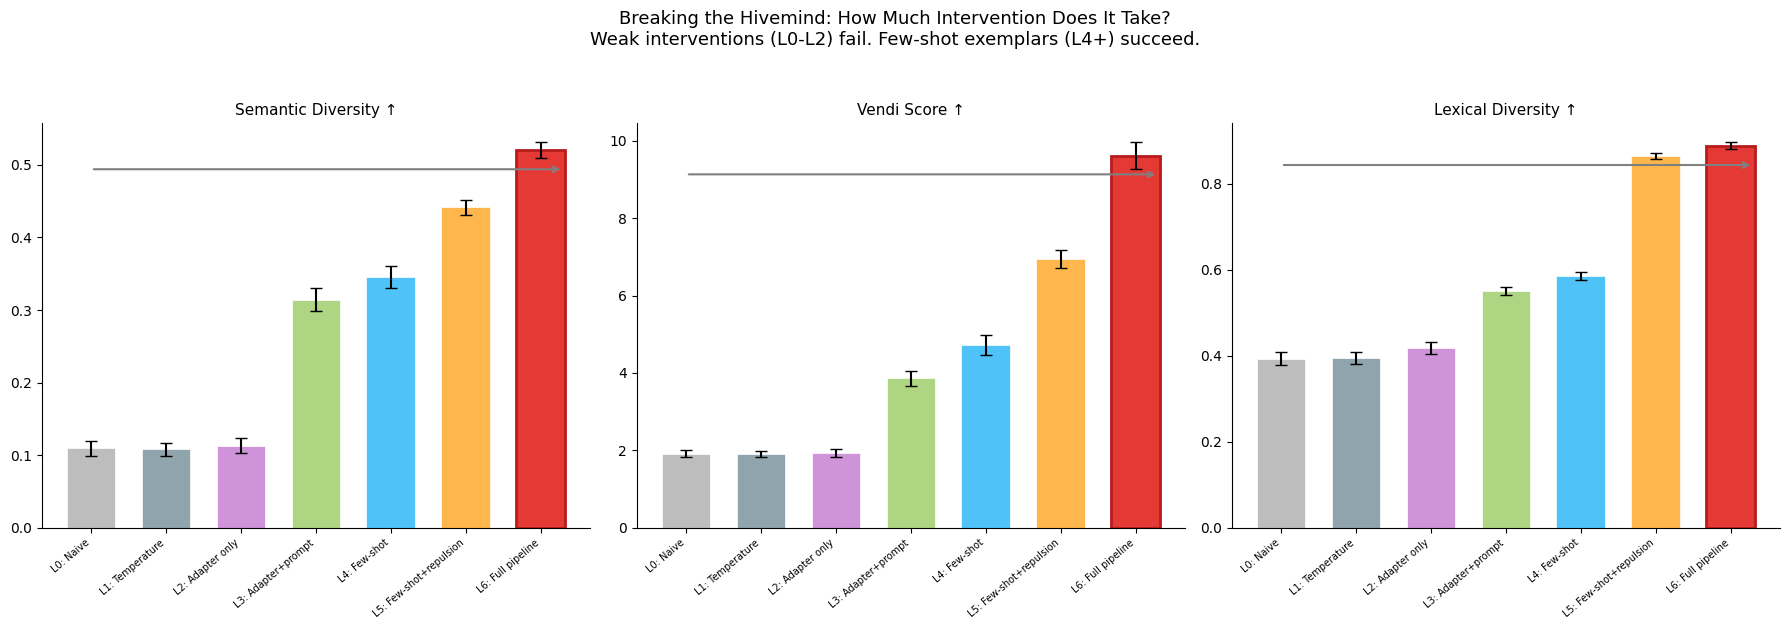

In [ ]:
COLORS = {
    'L0_naive': '#BDBDBD',
    'L1_temperature': '#90A4AE',
    'L2_adapter_only': '#CE93D8',
    'L3_adapter_prompt': '#AED581',
    'L4_fewshot': '#4FC3F7',
    'L5_fewshot_repulsion': '#FFB74D',
    'L6_full_pipeline': '#E53935',
}
level_order = list(LEVELS.keys())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, metric, title in zip(axes,
    ['SemDiv', 'Vendi', 'LexDiv'],
    ['Semantic Diversity ↑', 'Vendi Score ↑', 'Lexical Diversity ↑']
):
    means = [agg[l][metric]['mean'] for l in level_order]
    ses = [agg[l][metric]['se'] for l in level_order]
    colors = [COLORS[l] for l in level_order]

    bars = ax.bar(range(7), means, color=colors,
                  yerr=ses, capsize=4, width=0.65, edgecolor='white', linewidth=0.5)
    bars[-1].set_edgecolor('#B71C1C'); bars[-1].set_linewidth(2)

    ax.set_xticks(range(7))
    ax.set_xticklabels([LEVEL_LABELS[l] for l in level_order],
                       rotation=40, ha='right', fontsize=7)
    ax.set_title(title, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.annotate('', xy=(6.3, max(means)*0.95), xytext=(0, max(means)*0.95),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

plt.suptitle('Breaking the Hivemind: How Much Intervention Does It Take?\n'
             'Weak interventions (L0-L2) fail. Few-shot exemplars (L4+) succeed.',
             fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, 'fig1_ladder.png'),
            dpi=200, bbox_inches='tight')
plt.show()

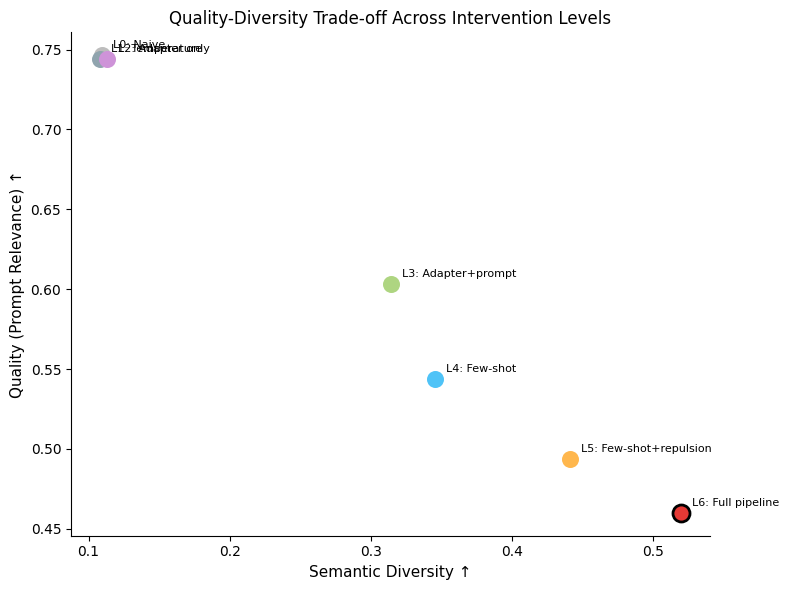

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for level in level_order:
    x = agg[level]['SemDiv']['mean']
    y = agg[level]['Quality']['mean']
    ax.scatter(x, y, c=COLORS[level], s=150, zorder=3,
               edgecolors='black' if level == 'L6_full_pipeline' else COLORS[level],
               linewidth=2 if level == 'L6_full_pipeline' else 0)
    ax.annotate(LEVEL_LABELS[level], (x, y),
                textcoords='offset points', xytext=(8, 5), fontsize=8)

ax.set_xlabel('Semantic Diversity ↑', fontsize=11)
ax.set_ylabel('Quality (Prompt Relevance) ↑', fontsize=11)
ax.set_title('Quality-Diversity Trade-off Across Intervention Levels', fontsize=12)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(cfg.output_dir, 'fig2_pareto.png'),
            dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
for prompt in cfg.prompts[:2]:
    print(f'\n{"="*70}')
    print(f'Prompt: "{prompt}"')
    print(f'{"="*70}')
    for level in ['L0_naive', 'L2_adapter_only', 'L4_fewshot', 'L6_full_pipeline']:
        print(f'\n  --- {LEVEL_LABELS[level]} ---')
        for i, r in enumerate(all_responses[prompt][level][:3]):
            display = r[:150].replace('\n', ' ')
            if len(r) > 150: display += '...'
            print(f'  [{i+1}] {display}')


Prompt: "What does home mean to you?"

  --- L0: Naive ---
  [1] Home to me is a place where I feel safe, comfortable, and surrounded by the people and things that bring me joy. It's where I can relax and recharge a...
  [2] Home to me is a place of comfort, safety, and security where I can relax and recharge. It's the place where I can be myself, surround myself with love...
  [3] Home to me is a place where I feel safe, comfortable, and loved. It's the place where I can relax, unwind, and be myself without any judgment or press...

  --- L2: Adapter only ---
  [1] Home to me is a place where I feel safe, comfortable, and relaxed. It's the place where I can be myself, free from judgement or criticism. Home is whe...
  [2] Home to me is a place where I feel a sense of comfort, safety, and belonging. It's the place where I can relax, unwind, and be myself without any judg...
  [3] To me, home is a place where I feel a deep sense of comfort, safety, and belonging. It is the place where 

In [ ]:
output = {
    'config': {'model': cfg.base_model_id, 'K': cfg.K, 'seed': cfg.seed},
    'aggregated': {l: {m: {'mean': float(agg[l][m]['mean']),
                           'se': float(agg[l][m]['se'])}
                       for m in METRICS} for l in LEVELS},
    'per_prompt': per_prompt,
    'responses': all_responses,
}
path = os.path.join(cfg.output_dir, 'ladder_results.json')
with open(path, 'w') as f:
    json.dump(output, f, indent=2, default=float)
print(f'Saved: {path}')

Saved: ./hivemind_ladder_results/ladder_results.json


In [ ]:
from google.colab import drive
import os, json, shutil
from datetime import datetime

drive.mount('/content/drive')

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
drive_dir = f"/content/drive/MyDrive/hivemind_ladder_results_{timestamp}"
os.makedirs(drive_dir, exist_ok=True)

output = {
    "config": {
        "model": cfg.base_model_id,
        "K": cfg.K,
        "seed": cfg.seed,
        "prompts": cfg.prompts,
    },
    "aggregated": {
        level: {
            metric: {
                "mean": float(agg[level][metric]["mean"]),
                "se": float(agg[level][metric]["se"])
            }
            for metric in METRICS
        }
        for level in LEVELS
    },
    "per_prompt": per_prompt,
    "responses": all_responses,
}

json_path = os.path.join(drive_dir, "ladder_results_full.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False, default=float)

txt_path = os.path.join(drive_dir, "all_responses_readable.txt")
with open(txt_path, "w", encoding="utf-8") as f:
    for prompt, levels in all_responses.items():
        f.write("=" * 100 + "\n")
        f.write(f"PROMPT: {prompt}\n")
        f.write("=" * 100 + "\n\n")

        for level, responses in levels.items():
            f.write(f"\n--- {level} ---\n\n")
            for i, response in enumerate(responses, 1):
                f.write(f"[Response {i}]\n")
                f.write(str(response))
                f.write("\n\n")

if os.path.exists(cfg.output_dir):
    copied_outputs_dir = os.path.join(drive_dir, "notebook_outputs")
    shutil.copytree(cfg.output_dir, copied_outputs_dir, dirs_exist_ok=True)

print("Saved everything to Google Drive:")
print(drive_dir)
print("Files saved:")
print("-", json_path)
print("-", txt_path)

Mounted at /content/drive
Saved everything to Google Drive:
/content/drive/MyDrive/hivemind_ladder_results_20260510_035551
Files saved:
- /content/drive/MyDrive/hivemind_ladder_results_20260510_035551/ladder_results_full.json
- /content/drive/MyDrive/hivemind_ladder_results_20260510_035551/all_responses_readable.txt
